In [4]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
from pathlib import Path 
import glob, os
import numpy as np
from utils.data_loader import load_vanhateren_raw, scale_luminance, random_crop
from utils.plotting import plot_examples
from sklearn.decomposition import PCA


In [30]:
## Global variables
n_images = 1000
patch_size = (50, 50)
n_crops_per_image = 60


In [31]:
rng = np.random.default_rng(0)

data_path = Path("vanhateren_iml/")
iml_files = np.array(sorted(data_path.glob("*.iml")), dtype=object)
local_selected = rng.choice(len(iml_files), size=n_images, replace=False)
selected_files = iml_files[local_selected]

first = load_vanhateren_raw(selected_files[0])
images = np.empty((len(selected_files), *first.shape), dtype=first.dtype)

for i, f in enumerate(selected_files):
    images[i] = scale_luminance(load_vanhateren_raw(f), percentile_scale=99, clip=True)

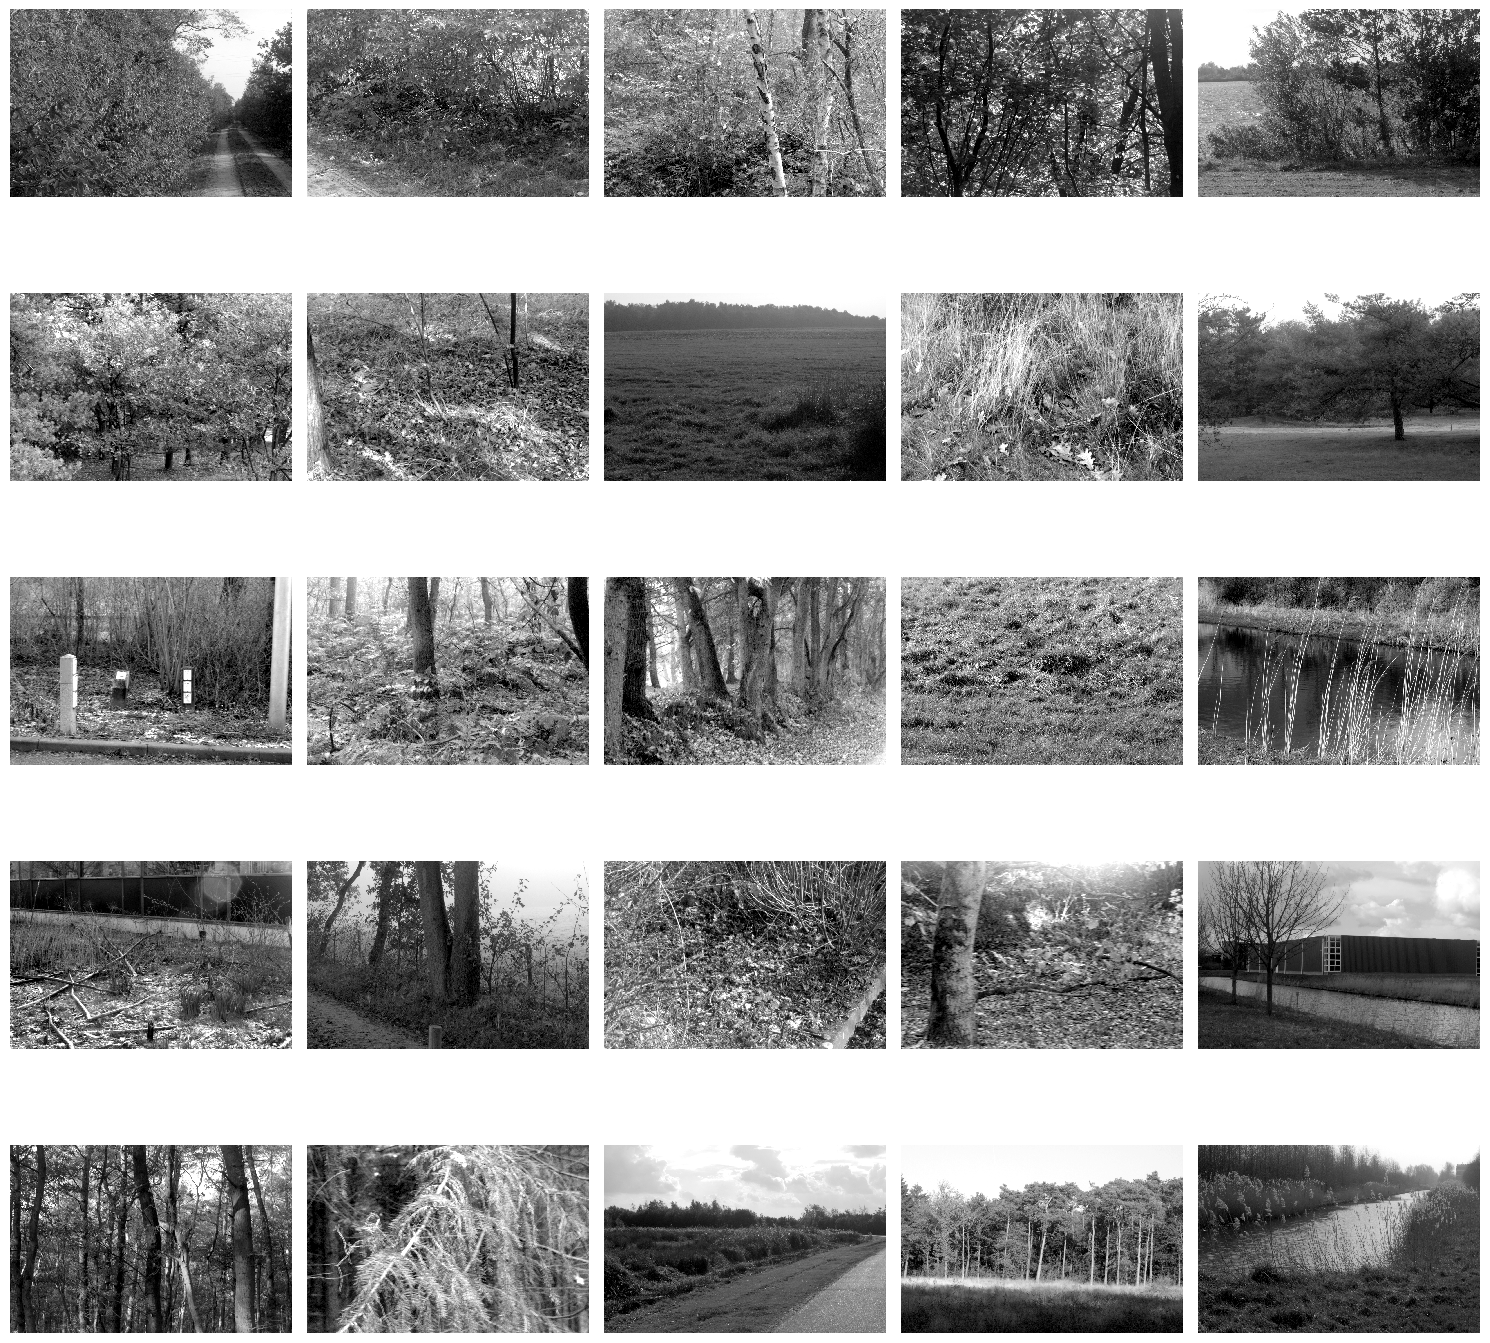

In [32]:
fig, axes = plot_examples(images, 5,5)

(60000, 50, 50)


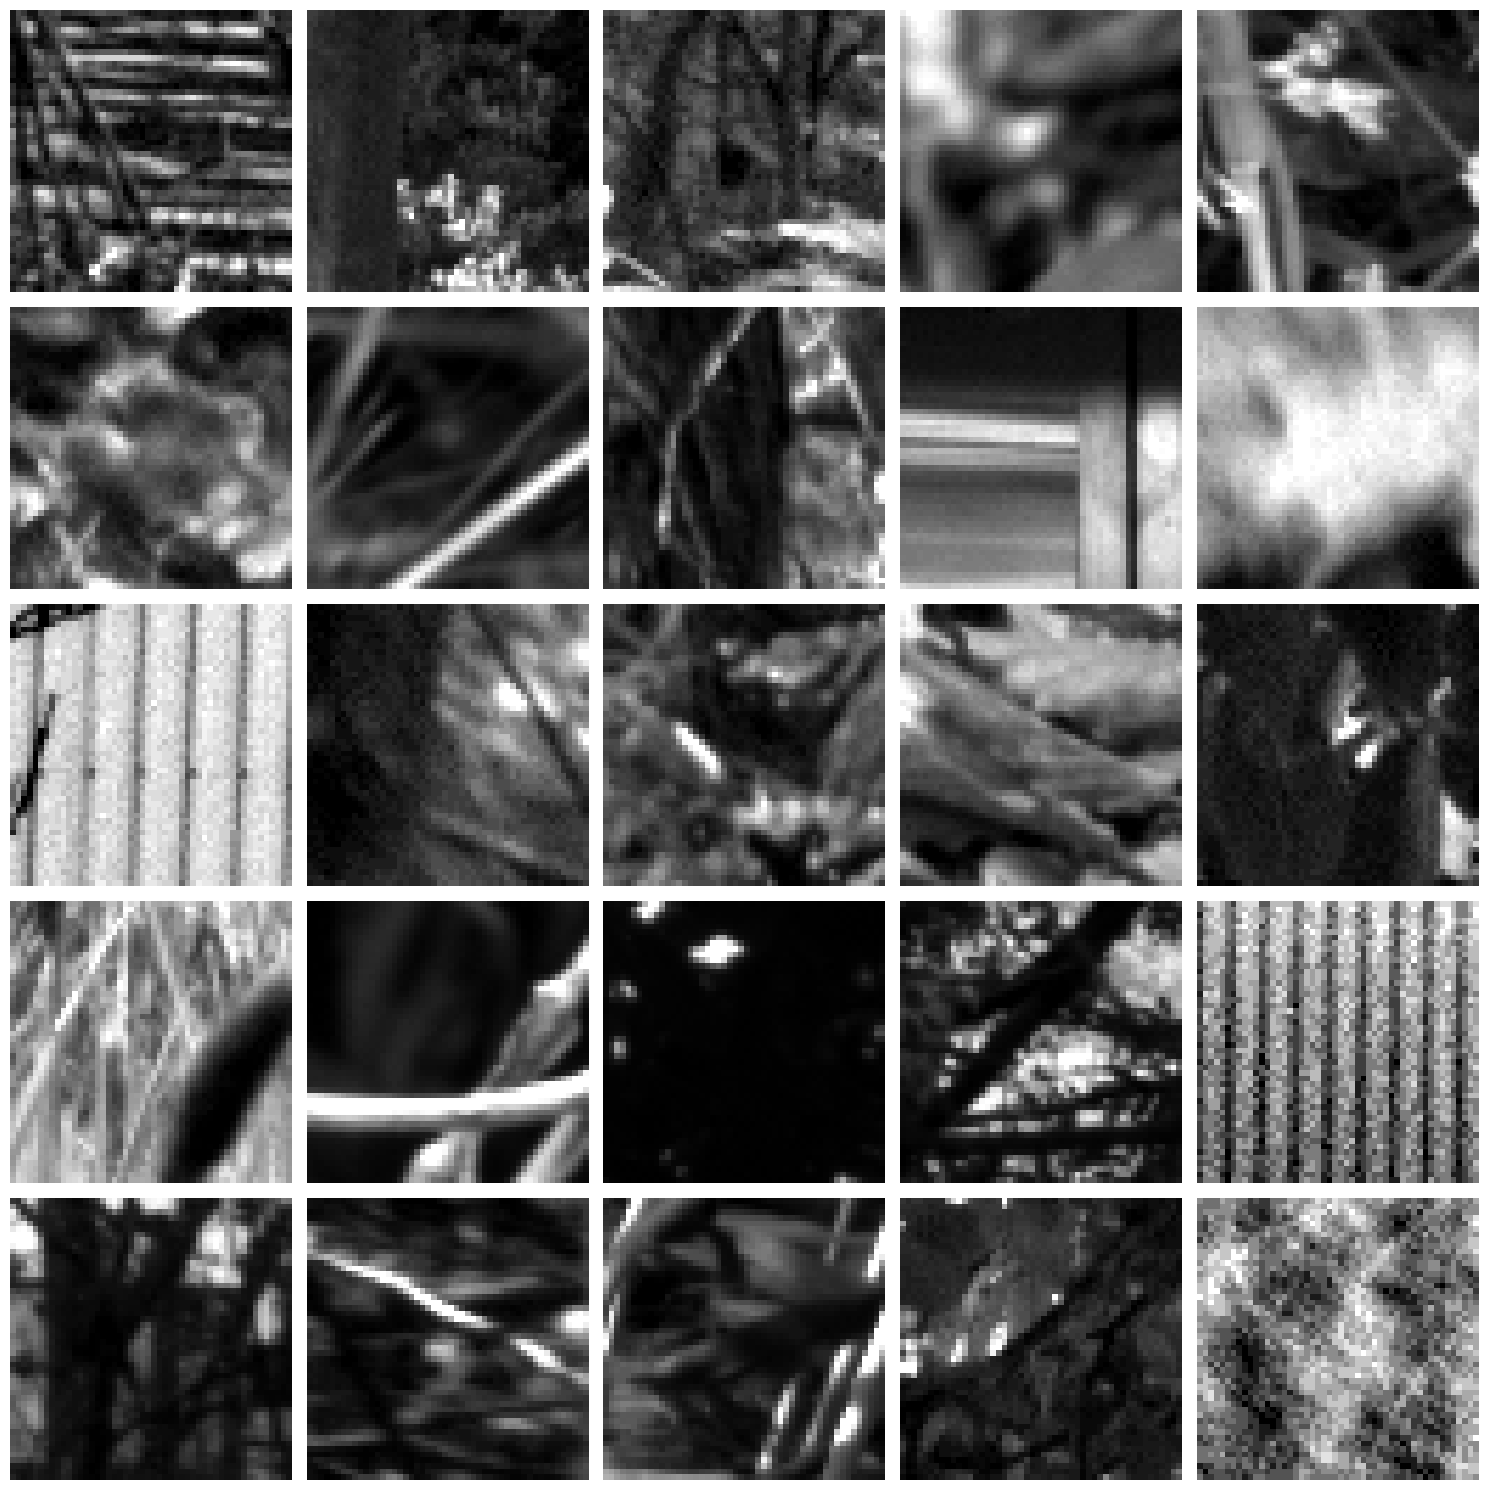

In [33]:
## Mean substract 
patches = np.stack([
    random_crop(img, rng, patch_size)
    for img in images
    for _ in range(n_crops_per_image)
], axis=0)

means = np.mean(patches,axis=(1,2))
patches -= means[:, np.newaxis, np.newaxis]
print(patches.shape)  # (n_images * n_crops_per_image, Hcrop,Wcrop)

fig, axes = plot_examples(patches, 5, 5, mode="linear")

In [34]:
X = patches.reshape(len(patches), -1).astype(np.float32)   # avoid mutating patches, use float32 for speed
print(X.shape)

dataset_mean = X.mean(axis=0)
X -= dataset_mean


(60000, 2500)


In [35]:
n_keep = X.shape[1]-1  
# pca = PCA(n_components=n_keep, svd_solver="randomized", random_state=0)
pca  = PCA(n_components=n_keep)
X_reduced = pca.fit_transform(X)

lam = pca.explained_variance_
k = np.arange(1, len(lam) + 1)
alpha = -np.polyfit(np.log(k[1:400]), np.log(lam[1:400]), 1)[0]
print("spectral exponent alpha ≈", alpha)

spectral exponent alpha ≈ 1.236035048847277


-1.2057196963022652


Text(0, 0.5, 'Variance')

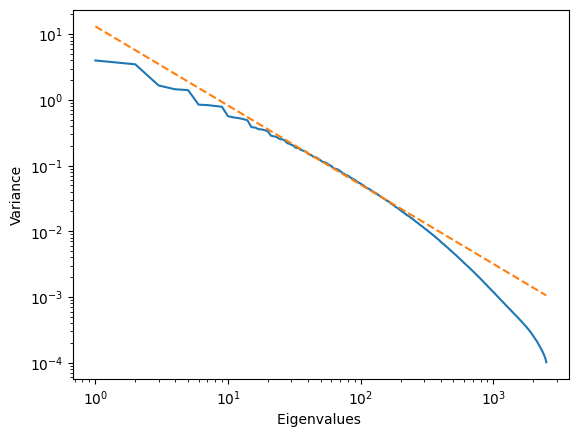

In [49]:
plt.loglog(np.arange(1, len(pca.explained_variance_)+1), 
           pca.explained_variance_)
x = np.linspace(1, X.shape[1]-1)
k = np.arange(1, len(lam)+1)
b, c = np.polyfit(np.log(k[20:200]), np.log(lam[20:200]), 1)
print(b)
plt.loglog(x, np.exp(c) * x**b, '--', label=r'$1/\lambda^\alpha$')
plt.xlabel("Eigenvalues ")
plt.ylabel("Variance")

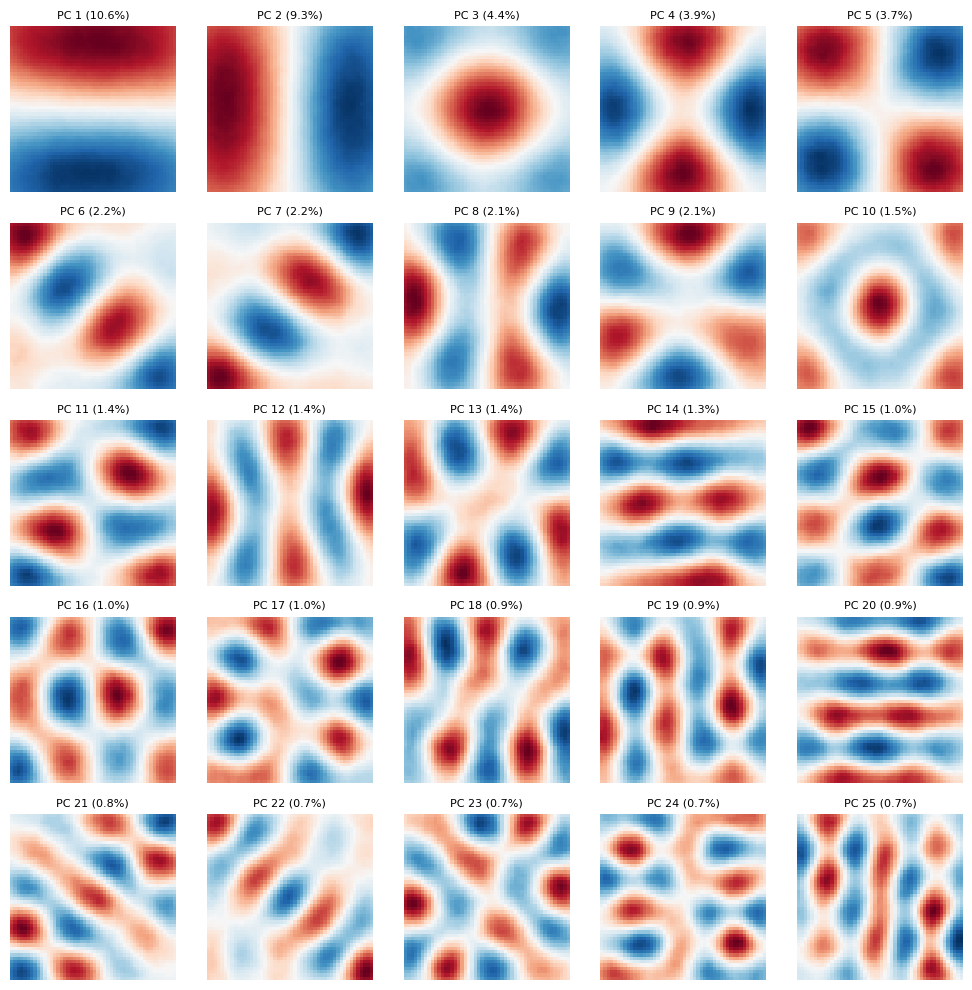

In [37]:
n_show = 25
n_rows, n_cols = 5, 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))

for i, ax in enumerate(axes.flat[:n_show]):
    eigvec = pca.components_[i].reshape(patch_size)
    vmax = np.abs(eigvec).max()
    ax.imshow(eigvec, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"PC {i+1} ({pca.explained_variance_ratio_[i]:.1%})", fontsize=8)
    ax.set_axis_off()

for ax in axes.flat[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

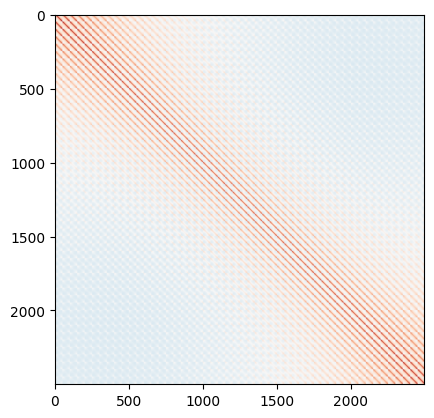

In [38]:
D = pca.get_covariance()
plt.imshow(D, cmap='RdBu_r', vmin=-np.abs(D).max(), vmax=np.abs(D).max())

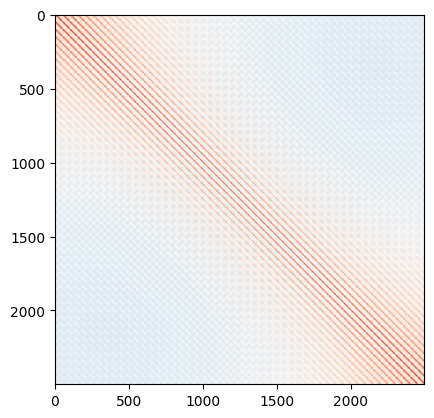

In [39]:
n_patches = patches.shape[0]
X = patches.reshape(n_patches, -1)  
X = X - X.mean(0)
C = np.cov(X, rowvar=False)        
plt.imshow(C, cmap='RdBu_r', vmin=-np.abs(C).max(), vmax=np.abs(C).max())

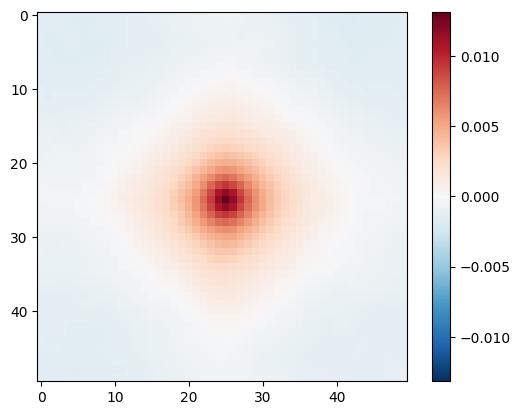

In [40]:
P = patch_size[0]
c = (P//2)*P + (P//2)
acf = C[c].reshape(P, P)

m = np.abs(acf).max()
plt.imshow(acf, cmap='RdBu_r', vmin=-m, vmax=m); plt.colorbar()

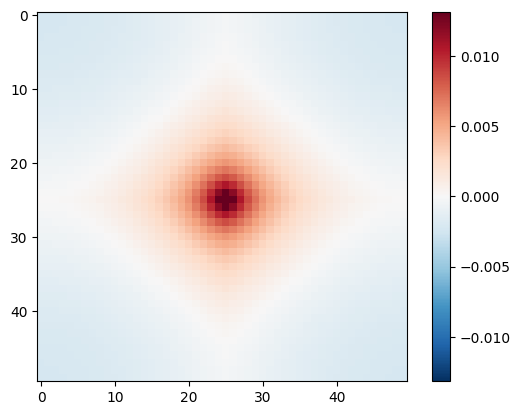

In [41]:
acf = np.zeros((P, P))
for i in range(P):
    for j in range(P):
        acf += np.roll(C[i*P + j].reshape(P, P), (P//2 - i, P//2 - j), axis=(0, 1))
acf /= P * P
plt.imshow(acf, cmap='RdBu_r', vmin=-m, vmax=m); plt.colorbar()

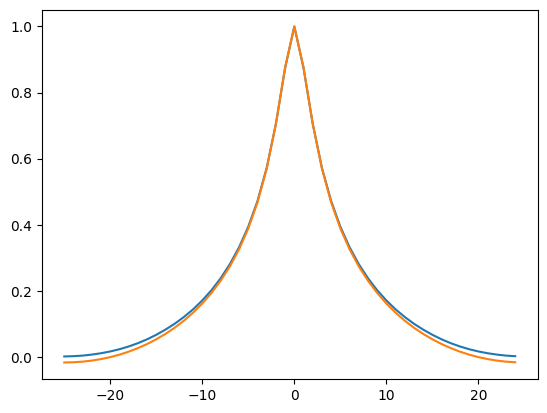

In [42]:
rx = acf[P//2, :] / acf[P//2, P//2]      # horizontal
ry = acf[:, P//2] / acf[P//2, P//2]      # vertical
d = np.arange(P) - P//2
plt.plot(d, rx)
plt.plot(d, ry)

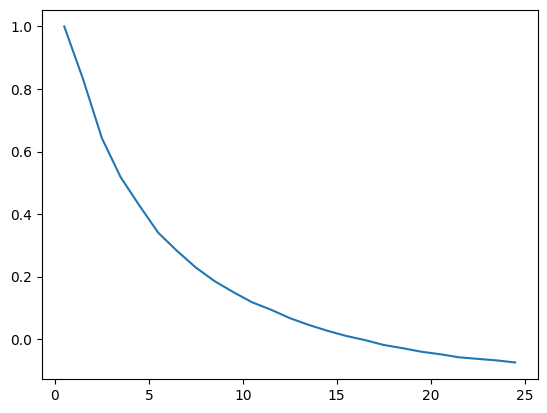

In [43]:
yy, xx = np.mgrid[0:P, 0:P] - P//2
dist = np.hypot(xx, yy).ravel()
bins = np.arange(0, P//2 + 1)
prof = np.array([acf.ravel()[(dist >= b) & (dist < b+1)].mean() for b in bins[:-1]])
plt.plot(bins[:-1] + 0.5, prof / prof[0])

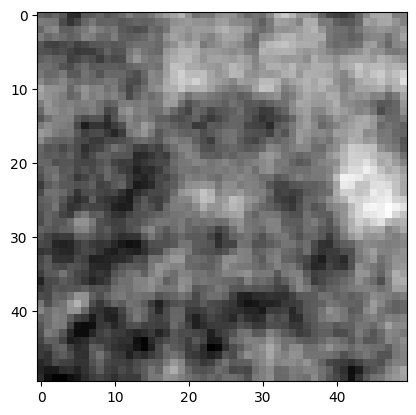

In [44]:
### PCA as generative model img ~ p(s)

coef = np.random.randn(pca.n_components_) * np.sqrt(pca.explained_variance_)
img  = (coef @ pca.components_ + pca.mean_).reshape(P,P)
plt.imshow(img, cmap='gray')

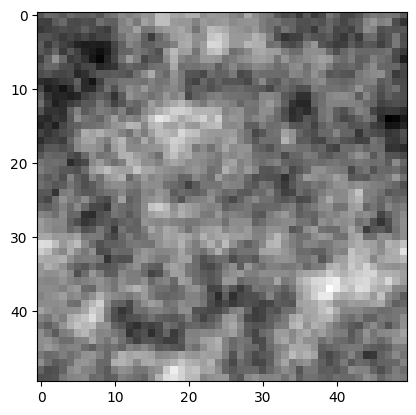

In [45]:
## 1/f gen model
N = 50
fy, fx = np.meshgrid(np.fft.fftfreq(N), np.fft.fftfreq(N), indexing='ij')
f = np.hypot(fx, fy); f[0,0] = 1
spec = np.fft.fft2(np.random.randn(N, N)) / f**(alpha)      # amplitude ~ 1/f, power ~ 1/f²
img = np.real(np.fft.ifft2(spec))
plt.imshow(img, cmap='gray')

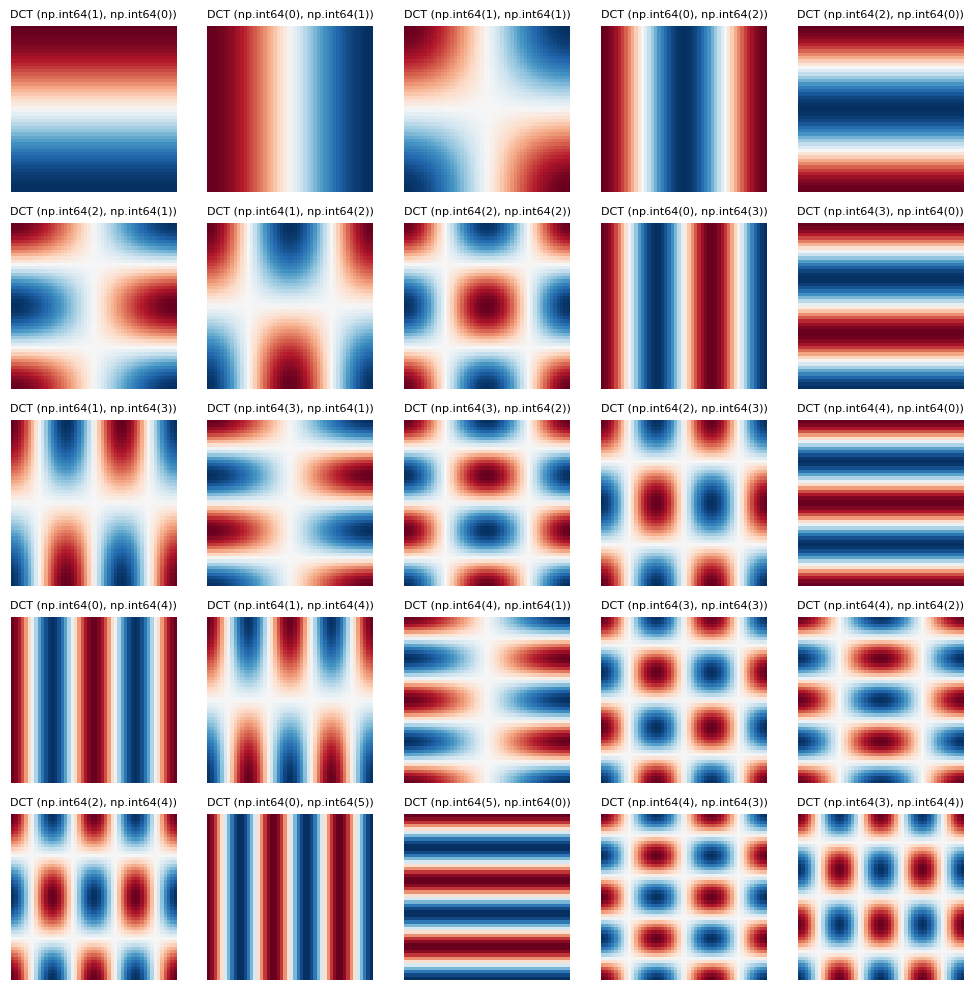

In [46]:
from scipy.fft import idctn

P = patch_size[0]
ky, kx = np.indices((P, P))
order = np.argsort(np.hypot(kx, ky).ravel())      # sort modes by radial frequency

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    i+=1
    basis = np.zeros(P*P); basis[order[i]] = 1
    b = idctn(basis.reshape(P, P), norm='ortho')
    v = np.abs(b).max()
    ax.imshow(b, cmap='RdBu_r', vmin=-v, vmax=v)
    ax.set_title(f"DCT {tuple(np.unravel_index(order[i], (P,P)))}", fontsize=8)
    ax.set_axis_off()
plt.tight_layout()

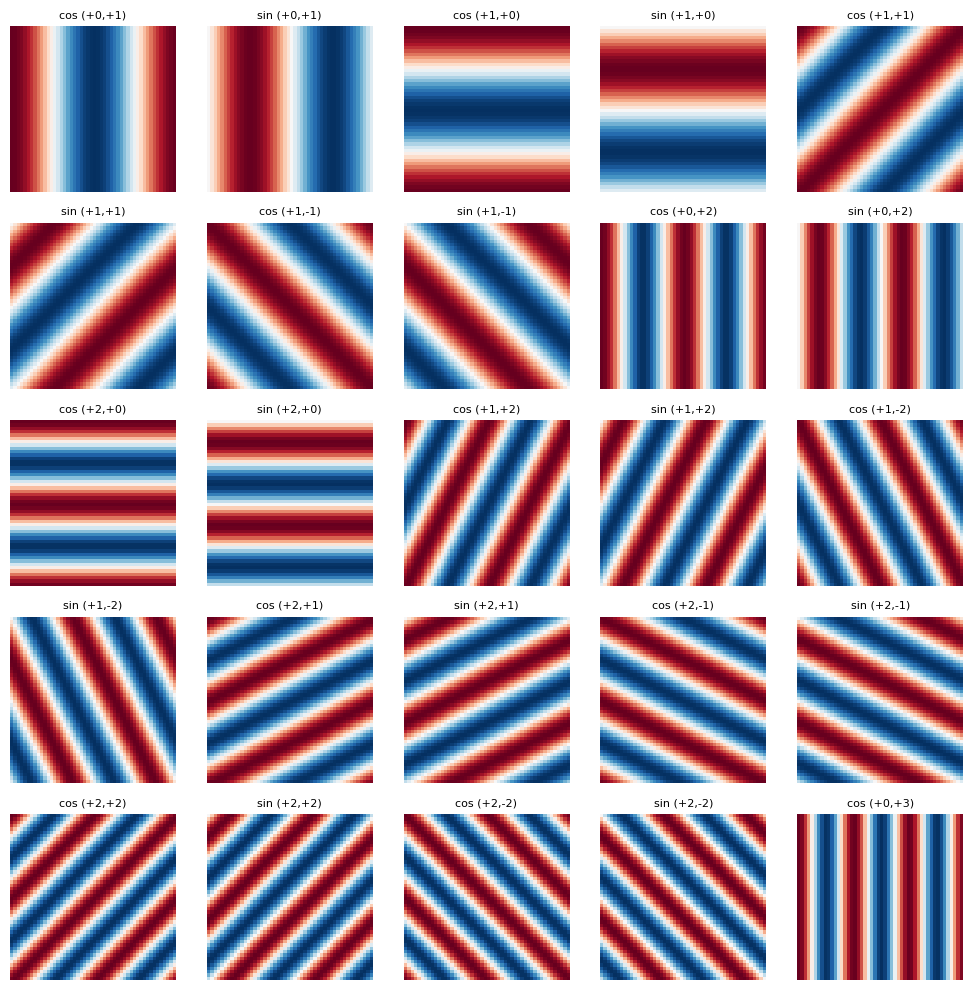

In [47]:
P = patch_size[0]
y, x = np.indices((P, P))
freqs = np.fft.fftfreq(P) * P          # integer cycles-per-patch, signed

# half-plane only: (fy,fx) and (-fy,-fx) are conjugates, same real modes
pairs = [(fy, fx) for fy in freqs for fx in freqs
         if (fy > 0) or (fy == 0 and fx > 0)]
pairs.sort(key=lambda p: np.hypot(*p))

modes = []
for fy, fx in pairs:
    ph = 2*np.pi*(fy*y + fx*x)/P
    modes.append((np.cos(ph), f"cos ({fy:+.0f},{fx:+.0f})"))
    modes.append((np.sin(ph), f"sin ({fy:+.0f},{fx:+.0f})"))

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, (b, lab) in zip(axes.flat, modes):
    v = np.abs(b).max()
    ax.imshow(b, cmap='RdBu_r', vmin=-v, vmax=v)
    ax.set_title(lab, fontsize=8)
    ax.set_axis_off()
plt.tight_layout()